Make sure you remove `raise NotImplementedError()` and fill in any place that says `# YOUR CODE HERE`, as well as your `NAME`, `ID`, and `SECTION` below:

---

Part 1: Polynomial Root Finding Using Bisection Method
---

### `pandas` Dataframe:
Before we start we will know a little about `pandas` dataframe. `pandas` is a python library. Dataframes are classes that are used to store complex data. You can initialize one as a python dictionary. Let's take a look.

In [84]:
import pandas as pd

x = [0, 1, 2, 3, 4, 5, 6, 7]
y = [1.0, 5.2, 3.9, 8.4, 14.6, 12.3, 8.9, 10.2]

dictionary = {
    "x": x,
    "y": y,
}
df = pd.DataFrame(dictionary)
df.head(8)

,x,y
0,0,1.0
1,1,5.2
2,2,3.9
3,3,8.4
4,4,14.6
5,5,12.3
6,6,8.9
7,7,10.2


We can use it to print data in a tabular format. We can even use more numpy arrays with it.

In [85]:
import numpy as np

x = np.linspace(0, np.pi/2, 15)
y = np.sin(x)

dictionary = {
    "x": x,
    "sin(x)": y,
}
df = pd.DataFrame(dictionary)
df.head(15)

,x,sin(x)
0,0.000000,0.000000
1,0.112200,0.111964
2,0.224399,0.222521
3,0.336599,0.330279
4,0.448799,0.433884
5,0.560999,0.532032
6,0.673198,0.623490
7,0.785398,0.707107
8,0.897598,0.781831
9,1.009798,0.846724


### Root Finding:
Let $f(x)$ be a function of $x$. if for some $x=\alpha, f(x) = f(\alpha) = 0$, we say $\alpha$ is a root of function $x$.

Let,
$$f(x) = x^5 + 2.5x^4 - 2x^3 -6x^2 + 0.5x + 2\tag{6.1}$$

The graph of $f(x)$ looks like this.

[-2.22027583 -1.61803399 -0.65499178  0.61803399  1.37526761]


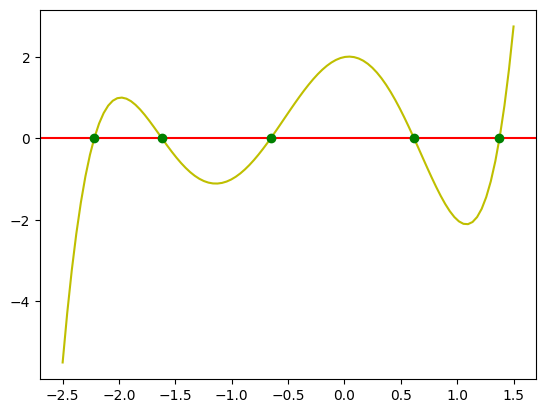

In [86]:
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt

f = Polynomial([2.0, 0.5, -6.0, -2.0, 2.5, 1.0])
x = np.linspace(-2.5, 1.5, 100)
y = f(x)
dictionary = {
    'x': x,
    'y': y
}
plt.axhline(y=0, color='r')
plt.plot(x, y,'y')
plt.plot(f.roots(), [0.0]*5, 'go')
print(f.roots())

Roots are the points where the graph intersects with the $X$-axis.

### Bisection

One way to find out root's are to use bisection method. Here is the strategy, if $\alpha$ is a root between and interval $[a, b]$ then graph will cross the $X$-axis at $\alpha$. So, $sign( f(\alpha-h) ) = - sign( f(\alpha+h) )$, for small value of $h$.

So, we can work our way up towards the root by taking average of $a$ and $b$, as long as the signs are different.

we will start with $a_0$ and $b_0$, such that, $f(a_0) f(b_0) < 0$.
Then we iterate as this,
\begin{align}
m_k &= \frac{a_k + b_k}{2} \\
\text{if, } f(a_k) f(m_k) < 0, \text{ then, } a_{k+1} &= a_k \text{ and } b_{k+1} = m_k\\
\text{else, } a_{k+1} &= m_k \text{ and, } b_{k+1} = b_k
\end{align}

We keep iterating until we find the root with sufficient precision. We usually use a formula like this,
$$
\frac{|m_{k+1} - m_k|}{|m_{k+1}|} \leq \epsilon \\  
$$
Where, $\epsilon$ is a very small value, like $\epsilon < 10^{-6}$

## Task 1 - 2 Marks
Complete the code below to iterate and solve for a root of the following equation, between the interval, $[-0.5, 1.3]$:
\begin{aligned}
    f(x) = 2 + 0.5x - 6x^2 - 2x^3 + 2.5x^4 + x^5.
\end{aligned}

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# The polynomial and the range is defined for you
f = Polynomial([2.0, 0.5, -6.0, -2.0, 2.5, 1.0])
a = -0.5
b = 1.3
m = (a + b) / 2
e = 1e-6

root = 0.0    # You need to update this value

# Populate the following lists in each iteration
list_a = []
list_b = []
list_m = []
list_f = []

# YOUR CODE HERE
root_found = False
while(not root_found):
    list_a.append(a)
    list_b.append(b)
    list_m.append(m)
    list_f.append(f(m))

    if f(a)*f(m)>0:
        a = m
    elif f(a)*f(m)<0:
        b = m
    elif f(a)*f(b)==0:
        root = m
        root_found=True
    old_m = m     #m of this iteration
    m = (a+b)/2   #m of next iteration
    modulus = (abs(m-old_m)/abs(m))
    if modulus<=e:
        root = m
        root_found=True

print(root)
# raise NotImplementedError()

0.6180344104766846


In [88]:
xs = np.linspace(-2.5, 1.5, 100)
ys = f(xs)

           a         b         m          f(m)
0  -0.500000  1.300000  0.400000  1.186240e+00
1   0.400000  1.300000  0.850000 -1.389529e+00
2   0.400000  0.850000  0.625000 -4.269409e-02
3   0.400000  0.625000  0.512500  6.189171e-01
4   0.512500  0.625000  0.568750  2.966661e-01
5   0.568750  0.625000  0.596875  1.286523e-01
6   0.596875  0.625000  0.610938  4.333223e-02
7   0.610938  0.625000  0.617969  3.991260e-04
8   0.617969  0.625000  0.621484 -2.112851e-02
9   0.617969  0.621484  0.619727 -1.035982e-02
10  0.617969  0.619727  0.618848 -4.979112e-03
11  0.617969  0.618848  0.618408 -2.289682e-03
12  0.617969  0.618408  0.618188 -9.452003e-04
13  0.617969  0.618188  0.618079 -2.730176e-04
14  0.617969  0.618079  0.618024  6.305907e-05
15  0.618024  0.618079  0.618051 -1.049781e-04
16  0.618024  0.618051  0.618037 -2.095919e-05
17  0.618024  0.618037  0.618031  2.105002e-05
18  0.618031  0.618037  0.618034  4.543651e-08
19  0.618034  0.618037  0.618036 -1.045687e-05
20  0.618034 

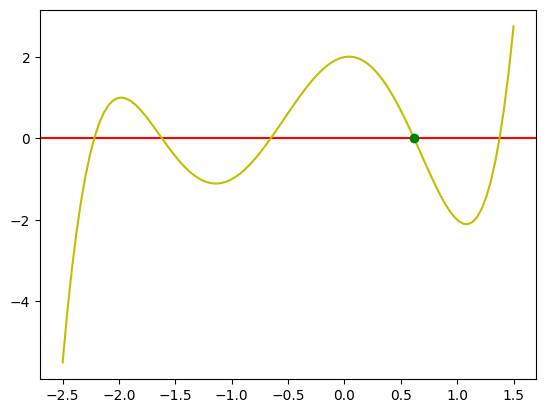

In [89]:
plt.axhline(y=0, color='r')
plt.plot(xs, ys,'y')
plt.plot(root, f(root), 'go')

print(pd.DataFrame({'a':list_a, 'b':list_b, 'm':list_m, 'f(m)':list_f}))

assert "{:.3f}".format(root) == "0.618"

# Part 2: Fixed Point Iteration

### Fixed point:
A number $\xi$ is called a **fixed point** to function $g(x)$ if $g(\xi) = \xi$. Using fixed points are a nice strategy to find roots of an equation. In this method if we are trying to find a root of $f(x) = 0$, we try to write the function in the form, $x = g(x)$. That is,
$$
f(x) = x - g(x) = 0
$$

So, if $\xi$ is a fixed point of $g(x)$ it would also be a root of $f(x)=0$, because,
$$
f(\xi) = \xi - g(\xi) = \xi - \xi = 0
$$

We can find a suitable $g(x)$ in any number of ways. Not all of them would converge; whereas, some would converge very fast. For example, consider $Eq. 6.1$.

\begin{align}
&         &    f(x) &=x^5 + 2.5x^4 - 2x^3 -6x^2 + x + 2 \\
&\implies &x - g(x) &=x^5 + 2.5x^4 - 2x^3 -6x^2 + x + 2 \\
&\implies &    g(x) &=-x^5 - 2.5x^4 + 2x^3 + 6x^2 - 2 \tag{6.2}\\
\end{align}

again,
$$
f(x) = x^5 + 2.5x^4 - 2x^3 -6x^2 + x + 2 = 0\\
$$
\begin{align}
&\implies &6x^2 &= x^5 + 2.5x^4 - 2x^3 + x + 2 \\
&\implies &x^2  &= \frac{1}{6}(x^5 + 2.5x^4 - 2x^3 + x + 2)\\
&\implies &x    &= \sqrt{\frac{1}{6}(x^5 + 2.5x^4 - 2x^3 + x + 2)}\\
&\implies &g(x) &= \sqrt{\frac{1}{6}(x^5 + 2.5x^4 - 2x^3 + x + 2)}\tag{6.3}\\
\end{align}

Similarly,
\begin{align}
&         &2.5x^4 &= -x^5 + 2x^3 + 6x^2 - x - 2 \\
&\implies &x^4  &= \frac{1}{2.5}(-x^5 + 2x^3 + 6x^2 - x - 2)\\
&\implies &x    &= \sqrt[\leftroot{-1}\uproot{2}\scriptstyle 4]{\frac{1}{2.5}(-x^5 + 2x^3 + 6x^2 - x - 2)}\\
&\implies &g(x) &= \sqrt[\leftroot{-1}\uproot{2}\scriptstyle 4]{\frac{1}{2.5}(-x^5 + 2x^3 + 6x^2 - x - 2)}\tag{6.4}\\
\end{align}

## Task 2 -  2 Marks
For this example we will use a couple of $g(x)$ function to find out which one converges faster.

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

f = Polynomial([2.0, 1.0, -6.0, -2.0, 2.5, 1.0])
g1 = Polynomial([-2.0, 0.0, 6.0, 2.0, -2.5, -1.0])

def g2(x):
    p = Polynomial([2.0, 1.0, 0.0, -2.0, 2.5, 1.0])
    return np.sqrt(p(x)/6)

def g3(x):
    p = Polynomial([-2.0, -1.0, 6.0, 2.0, 0.0, -1.0])
    return np.power(p(x)/2.5, 1.0/4.0)

a1 = 0.80
g1_a = []

a2 = 0.80
g2_a = []

a3 = 0.80
g3_a = []

# YOUR CODE HERE

g1_a.append(a1)
g2_a.append(a2)
g3_a.append(a3)

for i in range(50):
    x_1=g1(g1_a[i])
    g1_a.append(x_1)
    x_2 = g2(g2_a[i])
    g2_a.append(x_2)
    x_3=g3(g3_a[i])
    g3_a.append(x_3)
# raise NotImplementedError()

       g1(x)     g2(x)    g3(x))
0   0.800000  0.800000  0.800000
1   1.512320  0.721997  0.912898
2  -2.347605  0.688573  1.044444
3   0.562201  0.677301  1.160638
4  -0.054108  0.673860  1.241682
5  -1.982772  0.672844  1.288278
6  -1.995936  0.672547  1.311548
7  -1.999770  0.672460  1.322205
8  -1.999999  0.672435  1.326870
9  -2.000000  0.672427  1.328868
10 -2.000000  0.672425  1.329716
11 -2.000000  0.672425  1.330075
12 -2.000000  0.672424  1.330226
13 -2.000000  0.672424  1.330290
14 -2.000000  0.672424  1.330317
15 -2.000000  0.672424  1.330328
16 -2.000000  0.672424  1.330333
17 -2.000000  0.672424  1.330335
18 -2.000000  0.672424  1.330336
19 -2.000000  0.672424  1.330336
20 -2.000000  0.672424  1.330336
21 -2.000000  0.672424  1.330336
22 -2.000000  0.672424  1.330336
23 -2.000000  0.672424  1.330336
24 -2.000000  0.672424  1.330336
25 -2.000000  0.672424  1.330336
26 -2.000000  0.672424  1.330336
27 -2.000000  0.672424  1.330336
28 -2.000000  0.672424  1.330336
29 -2.0000

/tmp/ipykernel_794/3119428247.py:15: RuntimeWarning: invalid value encountered in power
  return np.power(p(x)/2.5, 1.0/4.0)


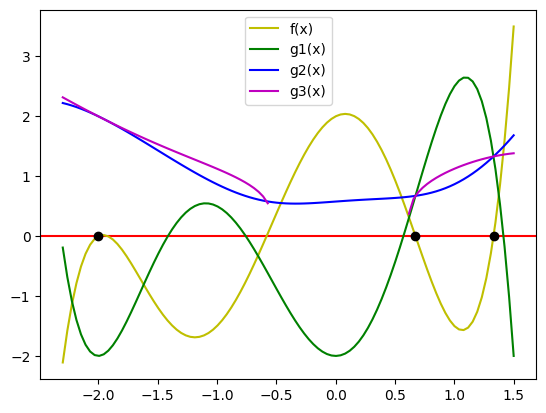

In [91]:
xs = np.linspace(-2.3, 1.5, 100)
ys = f(xs)
dictionary = {
    'x': xs,
    'y': ys
}
plt.axhline(y=0, color='r')
plt.plot(xs, f(xs), label='f(x)', color='y')
plt.plot(xs, g1(xs), label='g1(x)', color='g')
plt.plot(xs, g2(xs), label='g2(x)', color ='b')
plt.plot(xs, g3(xs), label='g3(x)', color = 'm' )
plt.legend()

if len(g1_a) > 0:
    root = np.array([g1_a[len(g1_a)-1], g2_a[len(g2_a)-1], g3_a[len(g3_a)-1]])
    plt.plot(root, f(root), 'ko')

print(pd.DataFrame({'g1(x)':g1_a, 'g2(x)':g2_a, 'g3(x))':g3_a,}))

# Test case:
np.testing.assert_array_almost_equal(root, [-2, 0.67242436, 1.33033625])

# Daily Evaluation - 4 Marks

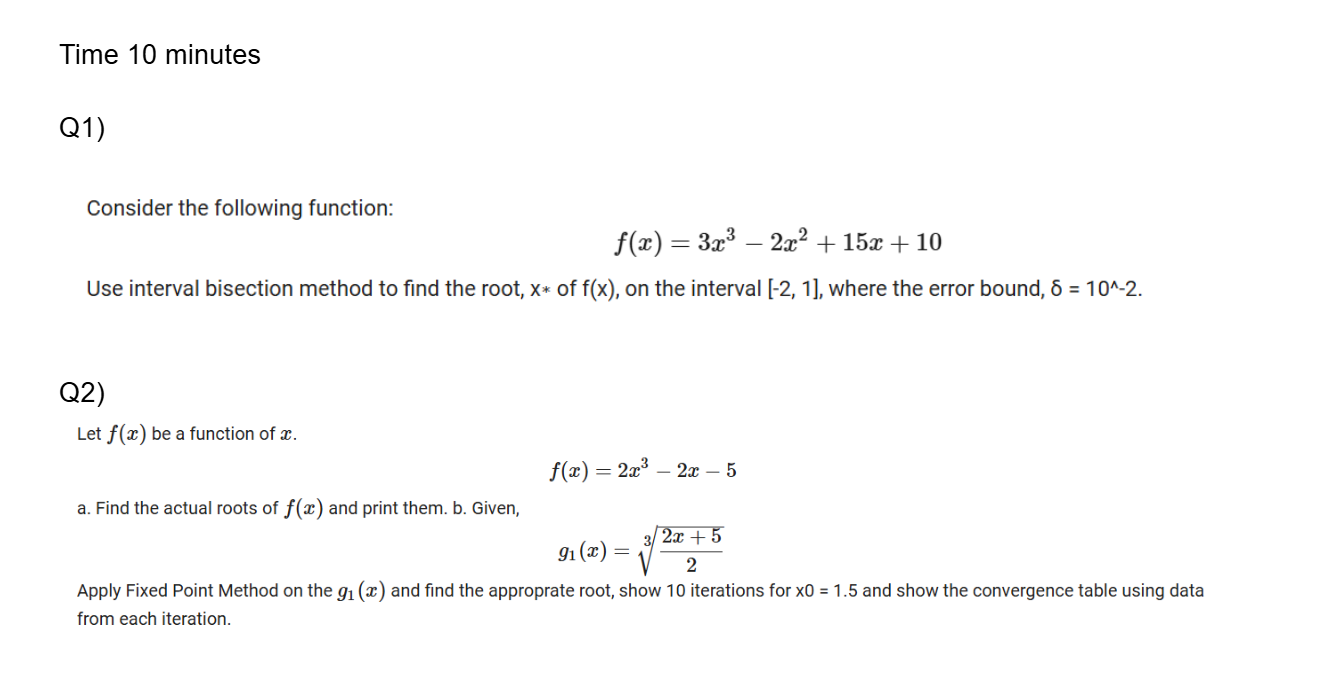

# Task -1


In [92]:
# The polynomial and the range is defined for you
f = Polynomial([10,15,-2,3])
a = -2
b = 1
m = (a + b) / 2
e = 1e-2

root = 0.0    # You need to update this value

# Populate the following lists in each iteration
list_a = []
list_b = []
list_m = []
list_f = []

# YOUR CODE HERE
root_found = False
while not root_found:
    list_a.append(a)
    list_b.append(b)
    list_m.append(m)
    list_f.append(f(m))

    if f(a)*f(m)>0:
        a = m
    elif f(a)*f(m)<0:
        b = m
    elif f(a)*f(b)==0:
        root = m
        root_found=True

    old_m = m     # m of this iteration
    m = (a+b)/2   # m of next iteration
    modulus = (abs(m-old_m)/abs(m))
    if modulus<=e:
        root = m
        root_found=True

print(f"Root found: {root}")

Root found: -0.587890625


# Task -2


In [93]:
f = Polynomial([-5, -2, 0, 2])
print("Polynomial:")
print(f)
roots = f.roots()
print("Actual Roots:")
print(roots)

Polynomial:
-5.0 - 2.0·x + 0.0·x² + 2.0·x³
Actual Roots:
[-0.80029927-0.95991498j -0.80029927+0.95991498j  1.60059854+0.j        ]


In [94]:
# g1(x) = (2x + 5) / 2x^2
def g1(x):
    return (2*x + 5) / (2 * (x**2))

# g2(x) = sqrt((2x + 5) / 2x)
def g2(x):
    return np.sqrt((2*x + 5) / (2 * x))

# g3(x) = cubert((2x + 5) / 2)
def g3(x):
    return np.power((2*x + 5) / 2, 1/3)

a1 = 1.80
g1_a = []

a2 = 1.80
g2_a = []

a3 = 1.80
g3_a = []

# YOUR CODE HERE

g1_a.append(a1)
g2_a.append(a2)
g3_a.append(a3)

for i in range(10):
    x_1=g1(g1_a[i])
    g1_a.append(x_1)
    x_2 = g2(g2_a[i])
    g2_a.append(x_2)
    x_3=g3(g3_a[i])
    g3_a.append(x_3)

In [95]:
root = np.array([g1_a[len(g1_a)-1], g2_a[len(g2_a)-1], g3_a[len(g3_a)-1]])

print(pd.DataFrame({'g1(x)':g1_a, 'g2(x)':g2_a, 'g3(x))':g3_a,}))
print(f"Root: {root}")

            g1(x)     g2(x)    g3(x))
0        1.800000  1.800000  1.800000
1        1.327160  1.545603  1.626133
2        2.172850  1.617866  1.603914
3        0.989743  1.595382  1.601030
4        3.562450  1.602193  1.600655
5        0.477695  1.600113  1.600606
6       13.049056  1.600747  1.600599
7        0.091316  1.600553  1.600599
8      310.762531  1.600612  1.600599
9        0.003244  1.600594  1.600599
10  237903.505376  1.600600  1.600599
Root: [2.37903505e+05 1.60059982e+00 1.60059855e+00]
